# Shuffle images

In [1]:
import itertools
import pathlib
from dataclasses import dataclass
import cv2
import numpy as np
from datetime import date
import imageio
from numba import jit
# from IPython import display
import random
from matplotlib import pyplot as plt
# from scipy.interpolate import interp1d

# import local modules
# from core.utils.binary_search_tree import BSTNode
from utils.renderer.giffer import create_gif

In [1]:
from core.utils.renderer.giffer import create_gif

## shuffle by pixel

In [54]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "image_shuffled"
mosaic_images_dir = project_dir / f"{project_name}"
mosaic_images_dir.mkdir(parents=True, exist_ok=True)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
photo = cv2.imread(photo_path)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg


In [58]:
# get current date
today = date.today().strftime("%Y%m%d")

photo_size = photo.size

nb_images = 60
# nb_images = photo.size//100

for shuffle_iteration in np.linspace(0, photo.size, nb_images, dtype=np.uint32):
    img = photo.copy()
    if shuffle_iteration == 0:
        shuffle_iteration = 1
    for i in range(shuffle_iteration):
        y1 = np.random.randint(0, photo.shape[0], size=1, dtype=np.uint32)
        x1 = np.random.randint(0, photo.shape[1], size=1, dtype=np.uint32)
        y2 = np.random.randint(0, photo.shape[0], size=1, dtype=np.uint32)
        x2 = np.random.randint(0, photo.shape[1], size=1, dtype=np.uint32)

        img[y1, x1, :] = img[y2, x2, :]

    # set output image & metadata paths
    out_img_path = str(mosaic_images_dir / f"shuffled_{shuffle_iteration:09d}_{today}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, img)

In [59]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/')
images_dir = project_dir / "image_shuffled"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'shuffling_{today}.gif'

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('*.jpg')
  filenames = sorted(filenames, reverse=True)

  # iterate over the images to add frame to gif
  for filename in filenames:
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    writer.append_data(image)

## shuffle by rectangles

In [60]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "image_shuffled_rect"
mosaic_images_dir = project_dir / f"{project_name}"
mosaic_images_dir.mkdir(parents=True, exist_ok=True)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
photo = cv2.imread(photo_path)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg


In [75]:
# get current date
today = date.today().strftime("%Y%m%d")

nb_images = 60
# nb_images = photo.size//100

width = 100
height = 200

for shuffle_iteration in np.linspace(0, photo.size//(200*100), nb_images, dtype=np.uint32):
    img = photo.copy()
    if shuffle_iteration == 0:
        shuffle_iteration = 1
    for i in range(shuffle_iteration):
        y1 = np.random.randint(0, photo.shape[0] - height, size=1, dtype=np.uint32)[0]
        x1 = np.random.randint(0, photo.shape[1] - width, size=1, dtype=np.uint32)[0]
        y2 = np.random.randint(0, photo.shape[0] - height, size=1, dtype=np.uint32)[0]
        x2 = np.random.randint(0, photo.shape[1] - width, size=1, dtype=np.uint32)[0]


        img[y2:y2 + height, x2:x2 + width, :] = img[y1:y1 + height, x1:x1 + width, :]

    # set output image & metadata paths
    out_img_path = str(mosaic_images_dir / f"shuffled_{shuffle_iteration:09d}_{today}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, img)

In [80]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/')
images_dir = project_dir / "image_shuffled_rect"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'shuffling_bigger_rect_{today}.gif'

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('*.jpg')
  filenames = sorted(filenames, reverse=True)

  # iterate over the images to add frame to gif
  for filename in filenames:
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    writer.append_data(image)

In [96]:
# Arrange all pixels into a tall column of 3 RGB values and find unique rows (colours)
colors, counts = np.unique(photo.reshape(-1,3), axis=0, return_counts=True)

# print most prominent color in photo
print(colors[counts.argmax()])

# get how many times the most prominent color appeas
print(counts.max())

[26  5  8]
117


## Recreate photo with pixel from another photo

In [52]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa')
project_name = "recreate_with_mona_lisa_pixels"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)


# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)
src_img = list(src_img.reshape(-1,3))

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/trump/to_recreate/Trump-Fagan.jpeg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height), interpolation=cv2.INTER_AREA)
# dest_img_hsv = cv2.cvtColor(dest_img, cv2.COLOR_BGR2HSV)
# dest_img = padded_img

# # get unique color values
# colors, counts = np.unique(src_img.reshape(-1,3), axis=0, return_counts=True)
# # #  Get pairs of elements
# # zip_iterator = zip(colors, counts)
# # # Convert into dict
# # colors_dict = dict(zip_iterator)

# bst = BSTNode()
# for color_idx, color in enumerate(colors):
#     bst.insert(val=color, img_path=color_idx)
    
# iterate over each pixel in source in dest_img (same size as src_img)
# pixel_positions = itertools.product(range(src_img_width), range(src_img_height))
# iterate randomly
# pixel_positions = list(itertools.product(range(src_img_width), range(src_img_height)))
pixel_positions = [np.array(pixel_position, dtype=np.uint32) for pixel_position in itertools.product(range(src_img_width), range(src_img_height))]
# img_size = len(pixel_positions)*src_img_channel
random.shuffle(pixel_positions)
pixel_positions = np.array(pixel_positions)

@jit(nopython=True)
def recreate_image_with_same_pixels(src_img, dest_img, pixel_positions):
    for (x_i, y_i) in pixel_positions:
    # for i, (x_i, y_i) in enumerate(pixel_positions, start=1):
        # print(x_i, y_i)
        # print(f"{100*i//img_size} %")

        # get pixel in given photo to recreate
        dest_pixel = dest_img[y_i, x_i, :]
        # dest_pixel_hue = dest_img_hsv[y_i, x_i, 0] # get hue

        # inititiate tracker for best match to that pixel
        best_match = np.inf
        best_match_index = 0
        
        # _, best_mean, color_idx = bst.exists(dest_pixel)

        # delete bst node if hue counts = 0, meaning we have used all pixels of this hue
        # counts[color_idx] -= 1
        # if counts[color_idx] < 0:
        #     bst.delete(best_mean)

        # iterate over each 
        for src_pixel_idx, src_pixel in enumerate(src_img):

            # compare src pixel and dest pixel
            total_sum = np.sum(np.abs(dest_pixel - src_pixel))

            if total_sum < best_match:
                best_match = total_sum
                best_match_index = src_pixel_idx

        # take out src pixel from list of src pixels
        best_match_pixel = src_img.pop(best_match_index)

        # update dest pixel with best match
        dest_img[y_i, x_i, :] = best_match_pixel
        # dest_img[y_i, x_i, :] = np.array(best_match_img, dtype=np.uint8)
        # dest_img[y_i, x_i, :] = np.array(colors[color_idx], dtype=np.uint8)
        # print(best_match_img)

        # display.clear_output(wait=True)

    # dest_img = cv2.cvtColor(dest_img_hsv, cv2.COLOR_HSV2BGR)

    return dest_img

out_img = recreate_image_with_same_pixels(src_img, dest_img, pixel_positions)

# get current date
today = date.today().strftime("%Y%m%d")

# set output image path
out_img_path = str(images_dir / f"dest_{today}.jpg")

# save output image & metadata
cv2.imwrite(out_img_path, out_img)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg
/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/trump/to_recreate/Trump-Fagan.jpeg


/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/ir_utils.py:2119: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'pixel_positions' of function 'recreate_image_with_same_pixels'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "<ipython-input-52-af11b2766804>", line 46:
@jit(nopython=True)
def recreate_image_with_same_pixels(src_img, dest_img, pixel_positions):
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))
/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/ir_utils.py:2119: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'src_img' of function 'recreate_image_with_same_pixels'.

For more information visit https://numba.pyda

True

### make gif from recreating image with another image
place the source image and dest image next to each other and show the pixels being transfered

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg


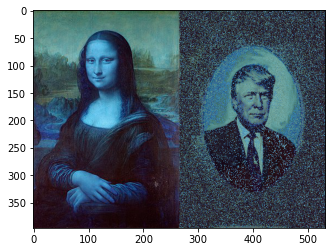

In [57]:
# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/mona_lisa/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)

stacked_img = cv2.hconcat([src_img, out_img])
plt.imshow(stacked_img)



In [ ]:
out_img_with_lines = out_img.copy()
cv2.addWeighted()

In [127]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte')
project_name = "recreate_with_mona_lisa_pixels"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)


# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height), interpolation=cv2.INTER_AREA)
# dest_img_hsv = cv2.cvtColor(dest_img, cv2.COLOR_BGR2HSV)
# dest_img = padded_img

dest_canvas = np.zeros_like(dest_img)
# concatenate source and dest image
dest_img = cv2.hconcat([src_img, dest_img])
out_img = cv2.hconcat([src_img, dest_canvas])

# src_img = list(src_img.reshape(-1,3))

# # get unique color values
# colors, counts = np.unique(src_img.reshape(-1,3), axis=0, return_counts=True)
# # #  Get pairs of elements
# # zip_iterator = zip(colors, counts)
# # # Convert into dict
# # colors_dict = dict(zip_iterator)

# bst = BSTNode()
# for color_idx, color in enumerate(colors):
#     bst.insert(val=color, img_path=color_idx)

dest_img_height, dest_img_width, dest_img_channel = dest_img.shape
    
# iterate over each pixel in source in dest_img (same size as src_img)
# pixel_positions = itertools.product(range(src_img_width), range(src_img_height))
# iterate randomly
# pixel_positions = list(itertools.product(range(src_img_width), range(src_img_height)))
src_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2))]
# src_pixel_positions = [np.array(pixel_position, dtype=np.uint64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2))]
# src_pixel_positions = np.array(src_pixel_positions)

dest_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2, dest_img_width))]
# img_size = len(pixel_positions)*src_img_channel
random.shuffle(dest_pixel_positions)
dest_pixel_positions = np.array(dest_pixel_positions)

color = np.array((0,0,0), dtype=np.uint8)
line_color = np.array((0,0,255), dtype=np.uint8)

@jit(nopython=True)
def recreate_image_with_same_pixels(dest_img, out_img, src_pixel_positions, dest_pixel_positions, color, line_color):
# def recreate_image_with_same_pixels(src_img, dest_img, src_pixel_positions, dest_pixel_positions, color):
    for (y_i, x_i) in dest_pixel_positions:
    # for i, (x_i, y_i) in enumerate(pixel_positions, start=1):
        # print(x_i, y_i)
        # print(f"{100*i//img_size} %")

        # get pixel in given photo to recreate
        dest_pixel = dest_img[y_i, x_i, :]
        # dest_pixel_hue = dest_img_hsv[y_i, x_i, 0] # get hue

        # inititiate tracker for best match to that pixel
        best_match = np.inf
        best_match_index = 0
        
        # _, best_mean, color_idx = bst.exists(dest_pixel)

        # delete bst node if hue counts = 0, meaning we have used all pixels of this hue
        # counts[color_idx] -= 1
        # if counts[color_idx] < 0:
        #     bst.delete(best_mean)

        # iterate over each 
        for src_pixel_idx, (src_y, src_x) in enumerate(src_pixel_positions):

            # get source pixel
            src_pixel = dest_img[src_y, src_x, :]

            # compare src pixel and dest pixel
            total_sum = np.sum(np.abs(dest_pixel - src_pixel))

            if total_sum < best_match:
                best_match = total_sum
                best_match_index = src_pixel_idx

        # take out src pixel from list of src pixels
        # best_match_pixel = src_img.pop(best_match_index)
        (best_match_y, best_match_x) = src_pixel_positions.pop(best_match_index)

        best_src_pixel = out_img[best_match_y, best_match_x, :]

        # # draw line
        # delta_x = x_i - best_match_x
        # delta_y = y_i - best_match_y
        # if delta_x == 0:
        #     slope = 0
        # else:
        #     slope = delta_y/delta_x

        # range_x = np.arange(best_match_x, x_i, dtype=np.int64)

        # for x in range_x:
        #     y = round(y_i + x*slope)

        #     out_img[y, x, :] = best_src_pixel # line_color

        # update dest pixel with best match
        out_img[y_i, x_i, :] = best_src_pixel
        # dest_img[y_i, x_i, :] = np.array(best_match_img, dtype=np.uint8)
        # dest_img[y_i, x_i, :] = np.array(colors[color_idx], dtype=np.uint8)
        
        out_img[best_match_y, best_match_x, :] = color


        # turn src pixel to black
        
        # display.clear_output(wait=True)

    # dest_img = cv2.cvtColor(dest_img_hsv, cv2.COLOR_HSV2BGR)

    return src_pixel_positions, out_img

# get current date
today = date.today().strftime("%Y%m%d")

nb_images = 60
previous_count = 0
for count in np.linspace(0, len(dest_pixel_positions), nb_images, dtype=np.uint32):

    # out_img = recreate_image_with_same_pixels(src_img, dest_img, src_pixel_positions, dest_pixel_positions, color)
    src_pixel_positions, out_img = recreate_image_with_same_pixels(dest_img, out_img, src_pixel_positions, dest_pixel_positions[previous_count:count], color, line_color)

    # set output image path
    out_img_path = str(images_dir / f"dest_{today}_{count:09d}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, out_img)

    previous_count = count

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg
/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg


/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/ir_utils.py:2119: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'src_pixel_positions' of function 'recreate_image_with_same_pixels'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "<ipython-input-127-811011805fae>", line 61:
@jit(nopython=True)
def recreate_image_with_same_pixels(dest_img, out_img, src_pixel_positions, dest_pixel_positions, color, line_color):
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


KeyboardInterrupt: 

In [274]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/')
images_dir = project_dir / "transfer_monalisa_sonofman"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'move_{today}_quad3.gif'

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('move*.jpg')
  filenames = sorted(filenames, reverse=False)

  # iterate over the images to add frame to gif
  for filename in filenames:
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1), interpolation=cv2.INTER_AREA)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    writer.append_data(image)

### visualize pixels transfers

#### idea (not used)
for pixel_xy in pixel_xys:
    get src_xy -> dest_xy

for list_xy_to_change in big_list_xy_to_change:
    for xy in list_xy_to_change:
        move pixel to its next position
        previous position must go back to pixel in final image

### idea
visualize transfer from 2 photos in both directions

In [112]:
@jit(nopython=True)
def get_pixel_coords_map(dest_img, src_pixel_positions, dest_pixel_positions):
    # create empty lists (or arrays) to store coords mapping between source and dest images
    src_yxs = []
    dest_yxs = []

    for (y_i, x_i) in dest_pixel_positions:

        # get pixel in given photo to recreate
        dest_pixel = dest_img[y_i, x_i, :]

        # inititiate tracker for best match to that pixel
        best_match = np.inf
        best_match_index = 0
        
        # iterate over each 
        for src_pixel_idx, (src_y, src_x) in enumerate(src_pixel_positions):

            # get source pixel
            src_pixel = dest_img[src_y, src_x, :]

            # compare src pixel and dest pixel
            # total_sum = np.sum(np.abs(dest_pixel - src_pixel))
            # sum = np.sum(np.abs(dest_pixel - src_pixel))
            # r_m = 0.5 * (dest_pixel[2] + src_pixel[2])
            # delta_rgb = np.square(dest_pixel - src_pixel)
            # col_diff_pixel = np.sqrt(delta_rgb[2] * (2 + r_m / 256) + delta_rgb[1] * (4) + delta_rgb[0] * (2 + (255 - r_m) / 256))

            # compute difference
            # diff = cv2.add(image_A,-image_B)
            diff = dest_pixel - src_pixel

            # separate into L,A,B channel diffs
            diff_L = diff[0]
            diff_A = diff[1]
            diff_B = diff[2]

            # compute delta_e as mean over every pixel using equation from  
            # https://en.wikipedia.org/wiki/Color_difference#CIELAB_ΔE*
            total_sum = np.sqrt(diff_L*diff_L + diff_A*diff_A + diff_B*diff_B) # it's delta_e
            
            # # get mean of metrics
            # total_sum = (sum + col_diff_pixel)/2

            # get weighted arithmetic mean
            # total_sum = (0.3*sum + 0.7*col_diff_pixel)/1
            # total_sum = (0.3*sum + 0.7*col_diff_pixel)

            # # euclidean distance
            # total_sum = np.sum(np.square(dest_pixel - src_pixel))

            if total_sum < best_match:
                best_match = total_sum
                best_match_index = src_pixel_idx

        # take out src pixel from list of src pixels
        (best_match_y, best_match_x) = src_pixel_positions.pop(best_match_index)

        src_yxs.append((best_match_y, best_match_x))
        dest_yxs.append((y_i, x_i))

    return src_yxs, dest_yxs

# create class for mapping pixel from source image to dest image
@dataclass
class SourceToDest:
    src_yx: tuple
    dest_yx: tuple
    # slope:float
    X: np.array
    Y: np.array
    # interpolate: interp1d
    # line_range: range

def get_line_range(src_yx:tuple, dest_yx:tuple, step:int, interpolation:str):
    """
    Function to get line range from start yx coords and end yx coords

    # to try with np.linspace()
    """
    src_y, src_x = src_yx
    dest_y, dest_x = dest_yx

    delta_x = dest_x - src_x
    delta_y = dest_y - src_y

    if delta_x == 0:
        slope = 0
    else:
        slope = delta_y/delta_x

    X = np.linspace(src_x, dest_x, step, dtype=np.uint64)
    Y = np.linspace(src_y, dest_y, step, dtype=np.uint64)
    return X,Y
    # return X, interp1d(X, Y, kind=interpolation)

    # return slope, np.linspace(src_x, dest_x, step, dtype=np.uint64)
    # return range(src_x, dest_x, dtype=np.int64)

In [111]:
diff = np.array((1,2,3)) - np.array((3,4,5))

# separate into L,A,B channel diffs
diff_L = diff[0]
diff_A = diff[1]
diff_B = diff[2]

# compute delta_e as mean over every pixel using equation from  
# https://en.wikipedia.org/wiki/Color_difference#CIELAB_ΔE*
np.mean(np.sqrt(diff_L*diff_L + diff_A*diff_A + diff_B*diff_B) ), 

3.4641016151377544

### how to compute color difference/similarity
https://stackoverflow.com/questions/8863810/python-find-similar-colors-best-way 
https://stackoverflow.com/questions/60257518/how-can-i-calculate-the-colorspace-delta-e-in-python-using-only-opencv-numpy-sci


In [56]:
def col_diff(img_bgr1, img_bgr2):
    # img_bgr1 = cv2.imread(img1) # since opencv2 reads as B, G, R
    # img_bgr2 = cv2.imread(img2)
    r_m = 0.5 * (img_bgr1[:, :, 2] + img_bgr2[:, :, 2])
    delta_rgb = np.square(img_bgr1- img_bgr2)
    cols_diffs = delta_rgb[:, :, 2] * (2 + r_m / 256) + delta_rgb[:, :, 1] * (4) + delta_rgb[:, :, 0] * (2 + (255 - r_m) / 256)
    cols_diffs = np.sqrt(cols_diffs)            
    # lets normalized the values to range [0 , 1] 
    cols_diffs_min = np.min(cols_diffs)
    cols_diffs_max = np.max(cols_diffs)
    cols_diffs_normalized = (cols_diffs - cols_diffs_min) / (cols_diffs_max - cols_diffs_min)
    
    return np.sqrt(cols_diffs_normalized)

In [75]:
def col_diff_pixel(pixel_1, pixel_2):
    r_m = 0.5 * (pixel_1[2] + pixel_2[2])
    delta_rgb = np.square(pixel_1- pixel_2)
    col_diff = delta_rgb[2] * (2 + r_m / 256) + delta_rgb[1] * (4) + delta_rgb[0] * (2 + (255 - r_m) / 256)
    # col_diff = np.sqrt(col_diff)            
    
    # # lets normalized the values to range [0 , 1] 
    # col_diff_min = np.min(col_diff)
    # col_diff_max = np.max(col_diff)
    # col_diff_normalized = (col_diff - col_diff_min) / (col_diff_max - col_diff_min)
    
    # return np.sqrt(col_diff_normalized)
    return np.sqrt(col_diff)

In [73]:
# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height), interpolation=cv2.INTER_AREA)

diff = (col_diff(src_img, dest_img) * 255).astype(np.uint8)
cv2.imshow("diff", diff)
cv2.waitKey()

cv2.destroyAllWindows()
cv2.waitKey(1)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg
/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg


-1

In [11]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte')
project_name = "recreate_with_mona_lisa_pixels"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)


# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height), interpolation=cv2.INTER_AREA)
# dest_img_hsv = cv2.cvtColor(dest_img, cv2.COLOR_BGR2HSV)
# dest_img = padded_img

dest_canvas = np.zeros_like(dest_img)
# concatenate source and dest image
dest_img = cv2.hconcat([src_img, dest_img])
out_img = cv2.hconcat([src_img, dest_canvas])

# src_img = list(src_img.reshape(-1,3))

# # get unique color values
# colors, counts = np.unique(src_img.reshape(-1,3), axis=0, return_counts=True)
# # #  Get pairs of elements
# # zip_iterator = zip(colors, counts)
# # # Convert into dict
# # colors_dict = dict(zip_iterator)

# bst = BSTNode()
# for color_idx, color in enumerate(colors):
#     bst.insert(val=color, img_path=color_idx)

dest_img_height, dest_img_width, dest_img_channel = dest_img.shape
    
# iterate over each pixel in source in dest_img (same size as src_img)
# pixel_positions = itertools.product(range(src_img_width), range(src_img_height))
# iterate randomly
# pixel_positions = list(itertools.product(range(src_img_width), range(src_img_height)))
src_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2))]
# src_pixel_positions = [np.array(pixel_position, dtype=np.uint64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2))]
# src_pixel_positions = np.array(src_pixel_positions)

dest_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(dest_img_height), range(dest_img_width//2, dest_img_width))]
# img_size = len(pixel_positions)*src_img_channel
random.shuffle(dest_pixel_positions)
dest_pixel_positions = np.array(dest_pixel_positions)

color = np.array((0,0,0), dtype=np.uint8)
line_color = np.array((0,0,255), dtype=np.uint8)

# out_img = recreate_image_with_same_pixels(src_img, dest_img, src_pixel_positions, dest_pixel_positions, color)
src_yxs, dest_yxs = get_pixel_coords_map(dest_img, src_pixel_positions, dest_pixel_positions)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg
/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg


/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/ir_utils.py:2119: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'src_pixel_positions' of function 'get_pixel_coords_map'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "<ipython-input-11-5f292e0347b3>", line 61:
@jit(nopython=True)
def get_pixel_coords_map(dest_img, src_pixel_positions, dest_pixel_positions):
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


In [12]:
out_img = cv2.hconcat([src_img, dest_canvas])
img = out_img.copy()
# src_img_canvas = out_img.copy()
src_img_canvas = np.zeros_like(src_img)

# set pixel speed (every pixel should arrive to dest yx after 60 frames)
steps = 60

# create list of SourceToDest objects
pixels_map = [SourceToDest(src_yxs[i], dest_yxs[i], *get_line_range(src_yxs[i], dest_yxs[i], steps, interpolation="linear")) for i in range(len(src_yxs))]

# get current date
today = date.today().strftime("%Y%m%d")

origin_pixel = None
origin_y : None
origin_x: None

origin_pixels_yxs = []

alpha_range = np.linspace(0, 1, steps)

# # recreate image with another image
# for pixel_map in pixels_map:
#     # get src pixel coords
#     src_y, src_x = pixel_map.src_yx

#     # get dest pixel coords
#     dest_y, dest_x = pixel_map.dest_yx

#     # get src pixel
#     src_pixel = img[src_y, src_x, :]

#     # update dest pixel with src pixel
#     img[dest_y, dest_x, :] = src_pixel

#     # black out src pixel at src coords
#     img[src_y, src_x, :] = color

# move pixels from source position to destination position `steps`` times
for i in range(steps):

    for pixel_map in pixels_map:

        # if i > 0:
        #     # get origin pixel
        #     origin_y, origin_x = pixel_map.origin_pixel
        #     origin_pixel = img[origin_y, origin_x, :]

        # get src pixel coords
        src_y, src_x = pixel_map.src_yx

        # get src pixel
        src_pixel = out_img[src_y, src_x, :]

        # get new coords for src pixel
        new_x = pixel_map.X[i]
        new_y = pixel_map.Y[i]
        # new_y = int(pixel_map.interpolate(new_x))
        # new_y = round(src_y + new_x*pixel_map.slope)
        # new_y = round(pixel_map.dest_yx[0] + new_x*pixel_map.slope)

        # update image with src pixel at new coords
        img[new_y, new_x, :] = src_pixel

        # store orginal coords
        pixel_map.origin_pixel = (new_y, new_x)

        if i == 1:
            # black out src pixel at src coords
            img[src_y, src_x, :] = color
            # out_img[origin_y, origin_x, :] = origin_pixel

    # blend images: make first half slowly turning to black
    alpha = alpha_range[i]
    beta = 1 - alpha
    img[:,:img.shape[1]//2,:] = cv2.addWeighted(src_img_canvas[:,:img.shape[1]//2,:],alpha, img[:,:img.shape[1]//2,:],beta, 0)

    # for origin_pixel_yx in origin_pixels_yxs:
    #     out_img[origin_pixel_yx[0], origin_pixel_yx[1], :] = img[origin_pixel_yx[0], origin_pixel_yx[1], :]

    # set output image path
    out_img_path = str(images_dir / f"test_dest_{today}_{i:09d}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, img)

In [ ]:
# # draw line
# delta_x = x_i - best_match_x
# delta_y = y_i - best_match_y
# if delta_x == 0:
#     slope = 0
# else:
#     slope = delta_y/delta_x

# range_x = np.arange(best_match_x, x_i, dtype=np.int64)

# for x in range_x:
#     y = round(y_i + x*slope)

#     out_img[y, x, :] = best_src_pixel # line_color


### visualize transfer in both directions

In [113]:
# set project directory & directory where to save mosaic results images
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte')
project_name = "monalisa_sonofman_sum_lab_delta_e"
images_dir = project_dir / f"{project_name}"
images_dir.mkdir(parents=True, exist_ok=True)


# get source image
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg"
print(photo_path)
# src_img = cv2.resize(cv2.imread(photo_path), None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
src_img = cv2.imread(photo_path)
src_img_height, src_img_width, src_img_channel = src_img.shape
# # convert imgs to hsv
# src_img_hsv = cv2.cvtColor(src_img, cv2.COLOR_BGR2HSV)

# get photo to recreate
photo_path = "/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg"
print(photo_path)
dest_img = cv2.resize(cv2.imread(photo_path), (src_img_width, src_img_height), interpolation=cv2.INTER_AREA)
# dest_img_hsv = cv2.cvtColor(dest_img, cv2.COLOR_BGR2HSV)
# dest_img = padded_img

# concatenate source and dest image
top_img = cv2.hconcat([src_img, dest_img])
top_img = cv2.cvtColor(top_img, cv2.COLOR_BGR2LAB)
# bottom_img = cv2.hconcat([dest_img, src_img])
bottom_img = cv2.hconcat([src_img, dest_img])
bottom_img = cv2.cvtColor(bottom_img, cv2.COLOR_BGR2LAB)

# src_img = list(src_img.reshape(-1,3))

# # get unique color values
# colors, counts = np.unique(src_img.reshape(-1,3), axis=0, return_counts=True)
# # #  Get pairs of elements
# # zip_iterator = zip(colors, counts)
# # # Convert into dict
# # colors_dict = dict(zip_iterator)

# bst = BSTNode()
# for color_idx, color in enumerate(colors):
#     bst.insert(val=color, img_path=color_idx)

top_img_height, top_img_width, top_img_channel = top_img.shape
    
# iterate over each pixel in source in dest_img (same size as src_img)
# pixel_positions = itertools.product(range(src_img_width), range(src_img_height))
# iterate randomly
top_src_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(top_img_height), range(top_img_width//2))]
top_dest_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(top_img_height), range(top_img_width//2, top_img_width))]
random.shuffle(top_dest_pixel_positions)
top_dest_pixel_positions = np.array(top_dest_pixel_positions)

bottom_dest_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(top_img_height), range(top_img_width//2))]
bottom_src_pixel_positions = [np.array(pixel_position, dtype=np.int64) for pixel_position in itertools.product(range(top_img_height), range(top_img_width//2, top_img_width))]
random.shuffle(bottom_dest_pixel_positions)
bottom_dest_pixel_positions = np.array(bottom_dest_pixel_positions)

color = np.array((0,0,0), dtype=np.uint8)
line_color = np.array((0,0,255), dtype=np.uint8)

# out_img = recreate_image_with_same_pixels(src_img, dest_img, src_pixel_positions, dest_pixel_positions, color)
top_src_yxs, top_dest_yxs = get_pixel_coords_map(top_img, top_src_pixel_positions, top_dest_pixel_positions)
bottom_src_yxs, bottom_dest_yxs = get_pixel_coords_map(bottom_img, bottom_src_pixel_positions, bottom_dest_pixel_positions)

/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpeg
/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg


/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/numba/core/ir_utils.py:2119: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'src_pixel_positions' of function 'get_pixel_coords_map'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "<ipython-input-112-5604d563fa12>", line 2:
@jit(nopython=True)
def get_pixel_coords_map(dest_img, src_pixel_positions, dest_pixel_positions):
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


In [114]:
black_canvas = np.zeros_like(src_img)

top_out_img = cv2.hconcat([src_img, black_canvas])
bottom_out_img = cv2.hconcat([black_canvas, dest_img])
top_img = top_out_img.copy()
bottom_img = bottom_out_img.copy()


# src_img_canvas = out_img.copy()
src_img_canvas = np.zeros_like(src_img)
dest_img_canvas = np.zeros_like(dest_img)

# set pixel speed (every pixel should arrive to dest yx after 60 frames)
steps = 60

# create list of SourceToDest objects
top_pixels_map = [SourceToDest(top_src_yxs[i], top_dest_yxs[i], *get_line_range(top_src_yxs[i], top_dest_yxs[i], steps, interpolation="linear")) for i in range(len(top_src_yxs))]
bottom_pixels_map = [SourceToDest(bottom_src_yxs[i], bottom_dest_yxs[i], *get_line_range(bottom_src_yxs[i], bottom_dest_yxs[i], steps, interpolation="linear")) for i in range(len(bottom_src_yxs))]

# get current date
today = date.today().strftime("%Y%m%d")

# origin_pixel = None
# origin_y : None
# origin_x: None

# origin_pixels_yxs = []

alpha_range = np.linspace(0, 1, steps)

# # recreate image with another image
# for pixel_map in pixels_map:
#     # get src pixel coords
#     src_y, src_x = pixel_map.src_yx

#     # get dest pixel coords
#     dest_y, dest_x = pixel_map.dest_yx

#     # get src pixel
#     src_pixel = img[src_y, src_x, :]

#     # update dest pixel with src pixel
#     img[dest_y, dest_x, :] = src_pixel

#     # black out src pixel at src coords
#     img[src_y, src_x, :] = color

# move pixels from source position to destination position `steps`` times
for i in range(steps):

    for top_pixel_map, bottom_pixel_map in zip(top_pixels_map, bottom_pixels_map):

        # if i > 0:
        #     # get origin pixel
        #     origin_y, origin_x = pixel_map.origin_pixel
        #     origin_pixel = img[origin_y, origin_x, :]

        # get src pixel coords
        top_src_y, top_src_x = top_pixel_map.src_yx
        bottom_src_y, bottom_src_x = bottom_pixel_map.src_yx # should be dest_xy but no because of instantiation above

        # get src pixel
        top_src_pixel = top_out_img[top_src_y, top_src_x, :]
        bottom_src_pixel = bottom_out_img[bottom_src_y, bottom_src_x, :]

        # get new coords for src pixel
        top_new_x = top_pixel_map.X[i]
        top_new_y = top_pixel_map.Y[i]
        bottom_new_x = bottom_pixel_map.X[i]
        bottom_new_y = bottom_pixel_map.Y[i]
        # new_y = int(pixel_map.interpolate(new_x))
        # new_y = round(src_y + new_x*pixel_map.slope)
        # new_y = round(pixel_map.dest_yx[0] + new_x*pixel_map.slope)

        # update image with src pixel at new coords
        top_img[top_new_y, top_new_x, :] = top_src_pixel
        bottom_img[bottom_new_y, bottom_new_x, :] = bottom_src_pixel

        # store orginal coords
        # top_pixel_map.origin_pixel = (top_new_y, top_new_x)
        # bottom_pixel_map.origin_pixel = (bottom_new_y, bottom_new_x)

        # if i == 1:
        #     # black out src pixel at src coords
        #     top_img[top_src_y, top_src_x, :] = color
        #     bottom_img[bottom_src_y, bottom_src_x, :] = color
            # out_quad_img[origin_y, origin_x, :] = origin_pixel

    # blend top images: make first half slowly turning to black
    # blend bottom images: make second half slowly turning to black
    # top_y1, top_y2, top_x1, top_x2 = (0, src_img_canvas.shape[0], 0, src_img_canvas.shape[1])
    # bottom_y1, bottom_y2, bottom_x1, bottom_x2 = (src_img_canvas.shape[0], src_img_canvas.shape[0] + dest_img_canvas.shape[0], dest_img_canvas.shape[1], dest_img_canvas.shape[1] + dest_img_canvas.shape[1])

    alpha = alpha_range[i]
    beta = 1 - alpha

    top_img[:, :top_img.shape[1]//2,:] = cv2.addWeighted(src_img_canvas, alpha, top_img[:,:top_img.shape[1]//2, :],beta, 0)
    bottom_img[:, bottom_img.shape[1]//2:bottom_img.shape[1], :] = cv2.addWeighted(dest_img_canvas, alpha, bottom_img[:,bottom_img.shape[1]//2:bottom_img.shape[1], :], beta, 0)

    # for origin_pixel_yx in origin_pixels_yxs:
    #     out_img[origin_pixel_yx[0], origin_pixel_yx[1], :] = img[origin_pixel_yx[0], origin_pixel_yx[1], :]

    # set output image path
    out_img_path = str(images_dir / f"move_dest_{today}_{i:09d}.jpg")

    # save output image & metadata
    cv2.imwrite(out_img_path, cv2.vconcat([top_img, bottom_img]))

In [115]:
# create animated gif using the images saved

# set project directory & image directory
project_dir = pathlib.Path('/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/')
# images_dir = project_dir / "monalisa_sonofman_col_diff"

# set gif filename with current date
today = date.today().strftime("%Y%m%d")

gif_file = project_dir / f'move_{today}_quad_sum_lab_delta_e.gif'

duplicate_frame_amount = 3

# write gif within context manager
with imageio.get_writer(gif_file, mode='I') as writer:
  
  # get list of saved images and sort them
  filenames = images_dir.glob('move*.jpg')
  filenames = sorted(filenames, reverse=False)

  nb_images = len(filenames)

  # iterate over the images to add frame to gif
  for image_nb, filename in enumerate(filenames, start=1):
    image = cv2.imread(str(filename))
    image = cv2.resize(image, (image.shape[1]//1,image.shape[0]//1), interpolation=cv2.INTER_AREA)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # write several frames for beginning and ending
    if image_nb == 1 or image_nb == nb_images:
      for _ in range(duplicate_frame_amount):
        writer.append_data(image)
    writer.append_data(image)

In [1]:
from core.utils.renderer.giffer import create_gif
from core.utils.renderer.videographer import create_video
from pathlib import Path

In [2]:
img_dir = Path("/Users/derrickvanfrausum/Pictures")
out_gif_path = str(Path("/Users/derrickvanfrausum/Pictures")/"test.gif")
out_video_path = str(Path("/Users/derrickvanfrausum/Pictures")/"test.mp4")
create_gif(img_dir=img_dir, out_path=out_gif_path, out_img_shape=(200, 200), duplicate_end_img_amount=5)
create_video(img_dir=img_dir, out_path=out_video_path, fps=12)

In [5]:
img_extensions = {'.png', '.jpg', '.jpeg'}
[str(img_path) for img_path in img_dir.glob('**/*') if img_path.suffix in img_extensions]

['/Users/derrickvanfrausum/Pictures/1516903619995.jpeg',
 '/Users/derrickvanfrausum/Pictures/Snap Camera Photo 8.jpg',
 '/Users/derrickvanfrausum/Pictures/Snap Camera Photo 7.jpg',
 '/Users/derrickvanfrausum/Pictures/Snap Camera Photo 6.jpg',
 '/Users/derrickvanfrausum/Pictures/Snap Camera Photo 5.jpg',
 '/Users/derrickvanfrausum/Pictures/ti/Snap Camera Photo 6.jpg']

### pad & resize dest images to get same shape as src

(<AxesSubplot:title={'center':'CONSTANT'}>,
 Text(0.5, 1.0, 'CONSTANT'))

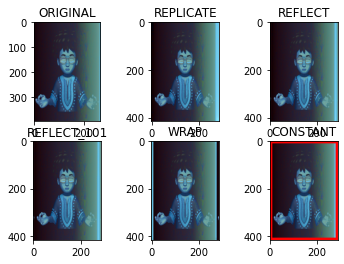

In [201]:
BLUE = [255,0,0]
replicate = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_WRAP)
constant= cv2.copyMakeBorder(dest_img,10,10,10,10,cv2.BORDER_CONSTANT,value=BLUE)
plt.subplot(231),plt.imshow(dest_img,'gray'),plt.title('ORIGINAL')
plt.subplot(232),plt.imshow(replicate,'gray'),plt.title('REPLICATE')
plt.subplot(233),plt.imshow(reflect,'gray'),plt.title('REFLECT')
plt.subplot(234),plt.imshow(reflect101,'gray'),plt.title('REFLECT_101')
plt.subplot(235),plt.imshow(wrap,'gray'),plt.title('WRAP')
plt.subplot(236),plt.imshow(constant,'gray'),plt.title('CONSTANT')

(<AxesSubplot:title={'center':'padded'}>,
 Text(0.5, 1.0, 'padded'))

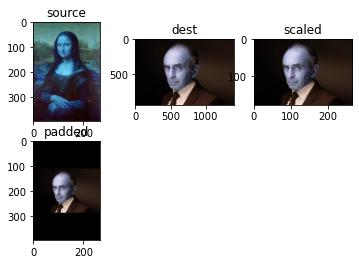

In [291]:
p1 = np.random.randint(0, 255, size=(3,4,3), dtype=np.uint8)
p2 = np.random.randint(0, 255, size=(5,5,3), dtype=np.uint8)

height, width = src_img_height, src_img_width
h, w = photo.shape[0], photo.shape[1]

pad_bottom, pad_right = 0, 0
ratio = w / h

if h > height or w > width:
    # shrinking image algorithm
    interp = cv2.INTER_AREA
else:
    # stretching image algorithm
    interp = cv2.INTER_CUBIC

w = width
h = round(w / ratio)

if h > height:
    h = height
    w = round(h * ratio)
    
pad_top= abs(height - h)//2 + 1
pad_bottom = abs(height - h)//2
# pad_left = abs(width - w)
# pad_right = abs(width - w)


scaled_img = cv2.resize(photo, (w, h), interpolation=interp)
padded_img = cv2.copyMakeBorder(scaled_img,pad_top,pad_bottom,pad_left,pad_right,borderType=cv2.BORDER_CONSTANT,value=[0,0,0])

plt.subplot(231),plt.imshow(src_img,'gray'),plt.title('source')
plt.subplot(232),plt.imshow(photo,'gray'),plt.title('dest')
plt.subplot(233),plt.imshow(scaled_img,'gray'),plt.title('scaled')
plt.subplot(234),plt.imshow(padded_img,'gray'),plt.title('padded')